# Lesson 10 homework

# Zadanie 10 – Broadcasting w praktyce

Dana tablica ocen (5 studentów x 4 egzaminy): 

exams = np.array([ [78, 85, 92, 88], [65, 72, 68, 70], [90, 88, 95, 92], [55, 60, 58, 62], [82, 79, 85, 80] ]) 

Dodaj bonus do każdego egzaminu: [5, 10, 5, 10] 

Następnie pomnóż wyniki każdego studenta przez mnożnik: [1.0, 1.1, 0.95, 1.15, 1.0] 

Wymagania: 
- Użyj broadcastingu (bez pętli) 
- Wypisz wyniki przed i po

In [3]:
import numpy as np

# Data
exams = np.array([ 
    [78, 85, 92, 88], 
    [65, 72, 68, 70], 
    [90, 88, 95, 92], 
    [55, 60, 58, 62], 
    [82, 79, 85, 80] ])

exam_bonus = np.array([5, 10, 5, 10])
multipliers = np.array([1.0, 1.1, 0.95, 1.15, 1.0]).reshape(5, 1)

# CALCULATION
# Broadcasting: (5, 4) + (4,) → (5, 4)
# NumPy rozciąga (4,) do (1, 4), a potem do (5, 4)
exams_with_bonus = exams + exam_bonus

# Broadcasting: (5, 4) * (5, 1) → (5, 4)
final_scores = exams_with_bonus * multipliers

# Result
print("Exams:\n", exams)
print("\nWith bonus:\n", exams_with_bonus)
print("\nFinal score:\n", final_scores)

Exams:
 [[78 85 92 88]
 [65 72 68 70]
 [90 88 95 92]
 [55 60 58 62]
 [82 79 85 80]]

With bonus:
 [[ 83  95  97  98]
 [ 70  82  73  80]
 [ 95  98 100 102]
 [ 60  70  63  72]
 [ 87  89  90  90]]

Final score:
 [[83.   95.   97.   98.  ]
 [77.   90.2  80.3  88.  ]
 [90.25 93.1  95.   96.9 ]
 [69.   80.5  72.45 82.8 ]
 [87.   89.   90.   90.  ]]


# Zadanie 11 – Analiza datasetu sprzedaży

Dataset: Sprzedaż 6 produktów w 30 dni

sales = np.random.randint(50, 200, size=(6, 30))

Oblicz:

- Trend sprzedaży per produkt (różnica między ostatnimi 7 dniami a pierwszymi 7 dniami)
- Najlepszy tydzień (dni 0-6, 7-13, 14-20, 21-27) dla całej sprzedaży
- Wykres: sprzedaż per produkt w czasie (linie)

Wymagania:
- Użyj slicingu do wycinania tygodni
- Wizualizacja matplotlib

Sales:
 [[ 97 167 117 153  59  71  86 137 120 138 190 108  89 137 138 131  75 127
  122  59 198 165 129 132 149  79 197 197 192  82]
 [ 59 177  82  81 164  78  84 178 178 103 183  88  67 129 182 155  92  81
  170  51 115 107  85 152 169  61 132 141 178 192]
 [149 103 190 171 134 118  56  97 177 181 150 128 193 198  73 191 167 135
   98  99 119 145 144  50 163  86  98 143 181 148]
 [ 92 162 199 177  50 188 164  93 177  73 180 171 148 112 173 132 198 100
   64  91 108  86  60 136  93 154  61  52 101 130]
 [ 82 178  88  69  92 165 127  80  74 175  52  53 144 157  63 162  90 122
   69 145 122 117 111  64 146  54 189 136 171 159]
 [125  66 199 160  75 171 168 167 133 154 171 120  81  63 121 129  91  68
   90  61 161 143 179 168  94 175  74 117  53  85]]

Trend sprzedaży (per produkt):
[ 278  300  -52 -305  118 -198]

Suma sprzedaży per tydzień:
[5193, 5547, 4938, 5133]

Najlepszy okazał się tydzień 2 z wynikiem 5547


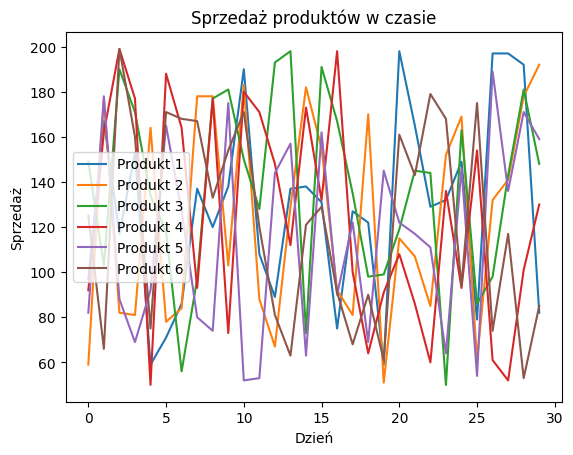

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Data
np.random.seed(0)  # dla powtarzalności
sales = np.random.randint(50, 200, size=(6, 30))
print(f'Sales:\n {sales}')

# Weekly sales
week1 = sales[:, 0:7]       # days 0-6
week2 = sales[:, 7:14]      # days 7-13
week3 = sales[:, 14:21]     # days 14-20
week4 = sales[:, 21:28]     # days 21-27

# Sales trend (1st and last 7 days)
last_seven_days = sales[:, -7:]     # last 7 days, days 23-29
trend = last_seven_days.sum(axis=1) - week1.sum(axis=1)

print("\nTrend sprzedaży (per produkt):")
print(trend)

# Best week
week_sums = [
    int(week1.sum()),
    int(week2.sum()),
    int(week3.sum()),
    int(week4.sum())
]
best_week = np.argmax(week_sums)

print("\nSuma sprzedaży per tydzień:")
print(week_sums)
print(f"\nNajlepszy okazał się tydzień {best_week+1} z wynikiem {week_sums[best_week]}")

# Sales chart
days = np.arange(30)

plt.figure()
for i in range(6):
    plt.plot(days, sales[i], label=f'Produkt {i+1}')
plt.xlabel("Dzień")
plt.ylabel("Sprzedaż")
plt.title("Sprzedaż produktów w czasie")

plt.legend()
plt.show()